# Project n°3 : Vision Transformers vs. Convolutional Neural Networks

**Authors** : Selim Ben Abdallah¹, Paola De Truchis¹, Eduardo De Jesus Zancanaro Garcia¹, and Edda Iveland¹ \
¹ INSA Toulouse

The goal of this project is to compare the performance of vision transformers (ViTs) to convolutional neural networks (CNNs) on the task of image classification on labelled datasets.

---
---

**Our notebook is structured as follows :**

1. **Presentation of the datasets**
- CIFAR-10
- Food-101 ?

2. **Convolution Neural Networks**
- Custom CNN, ResNet-18

3. **Vision Transformers**
- ViT-Tiny, Swin-Tiny

4. **Comparison**

5. **Conclusion**


---
---

In [60]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split, Subset

import utils.utils_metrics_project_3 as ump3
import utils.utils_train_eval_project_3 as utep3

importlib.reload(ump3)
importlib.reload(utep3)

from utils.utils_metrics_project_3 import get_confusion_matrix, plot_history, plot_confusion_matrix, pick_indices, show_predictions_grid, top_confusions, show_predictions_grid_viz
from utils.utils_train_eval_project_3 import train_model, train_model_resnet, evaluate

import models.models_project_3 as mp3
importlib.reload(mp3)
from models.models_project_3 import Custom_CNN, Custom_CNN_v2, ResNet18

In [61]:
TRAIN_CNN_V1_CIFAR = True
TRAIN_CNN_V2_CIFAR = True
TRAIN_CNN_V1_FOOD = True
TRAIN_CNN_V2_FOOD = True
TRAIN_RESNET_CIFAR = True
TRAIN_RESNET_FOOD = True

In [ ]:
# GDrive/Local paths to trained models

GDRIVE_PATH_TO_CNN_V1_CIFAR_30EP = "https://drive.google.com/drive/folders/1pYrSIe_KUytz0vsx1FLckBn284WWbQxt?usp=sharing"
GDRIVE_PATH_TO_CNN_V2_CIFAR_30EP = "https://drive.google.com/drive/folders/1E5z9nauWGNAe2UxLYiktyA7ReMsUSweP?usp=sharing"
GDRIVE_PATH_TO_RESNET_CIFAR_30EP = "https://drive.google.com/drive/folders/1yUzUwlN3g4J89DHmM8JSVYAu6dfHojYj?usp=sharing"

In [ ]:
## Comment below once the model weights are installed

## Weights for CNN/ResNet18 trainings 
#download_cnn_v1_cifar = download_gdrive_folder(GDRIVE_PATH_TO_CNN_V1_CIFAR_30EP, "weights/project_3/cnn_v1_cifar_30ep_30ep")
#download_cnn_v2_cifar = download_gdrive_folder(GDRIVE_PATH_TO_CNN_V2_CIFAR_30EP, "weights/project_3/cnn_v2_cifar_30ep_30ep")
#download_resnet_cifar = download_gdrive_folder(GDRIVE_PATH_TO_RESNET_CIFAR_30EP, "weights/project_3/cnn_v2_resnet_30ep_30ep")


## Weights for VIT trainings 

---
---

# Brainstorming + Infos

**Models**
- Custom CNN
- ResNet-18
- ViT-Tiny/16 (patch size : 16, embed dim : 192, depth : 12, heads : 3) (smaller than ViT B-16)
- Swin-T (Swin Tiny)

**Datasets**
- CIFAR-10 : 60k images, 32x32, 10 classes (50k train / 10k test)
- Food-101 : 101k images, 101 classes (750 train + 250 test per class, noisy training set)
- Important : For ImageNet-pretrained fine-tuning: resize/crop inputs to 224×224 for ResNet/ViT/Swin (and ideally also for the custom CNN for fair time/memory comparison)



**Training settings**
- Train from scratch on CIFAR-10 (4 from-scratch trainings)
- Train from scratch on Food-101 (4 from-scratch trainings)

| Dataset | Type | Custom CNN | ResNet-18 | ViT-Tiny | Swin-T |
|-----|-----|-----|-----|-----|-----|
| CIFAR-10 | From Scratch | 224 | 224 | 224 | 224 |
| Food-101 | From Scratch| 224 | 224 | 224 | 224 |

**Calculated metrics**
- best_val_acc : highest validation accuracy reached during training
- final_val_acc : validation accuracy after training fineshed, evaluated using the best weights
- final_test_acc : accuracy on the test set, using the best validation model
- final_val_macro_f1 : macro_f1 is the average of per-class f1_scores (each class contributes equally), final_val_marcro_f1 is the macro_f1 on the val set using the best model
- final_test_macro_f1 : macro_f1 on the test set using the best model
- total_training_time_sec : total training time in sec
- traink_peak_mem_bytes : The maximum torch.mps.current_allocated_memory() observed during training batches
- val_peak_mem_bytes : peak allocated memory observed during validation
- test_peak_mem_bytes : same for the test loop



---
---

## 1 - Datasets

### 1.1 - Dataset construction

#### 1.1.1 - CIFAR-10

The CIFAR-10 dataset contains 60000 labelled images of 10 classes: airplane, automobile, bird, cat, deer, dog, frog, horse, ship and truck. The images are coloured and of size 32x32. We will resize the images to 224x224 to feed to our CNNs and Vision Transformers. As the dataset is neither too big nor too small, we hope that differences in performance between CNNs and ViTs will not be due to the dataset scale, but rather the models themselves. (change comment)

We will we defining the ViT and CNN **from scratch**, so using a dataset that is easier to train from scratch is essential. If we were to use a dataset with larger images, pretrained weights would have yielded higher performance, making it harder to compare models from scratch. 

Each class in the CIFAR-10 dataset contains the **same number of images** and labels are clear and distinguished. Consequently, differences between CNNs and ViTs will not be due to class imbalances or noisy annotations. 

Additionally, CIFAR-10 has been **extensively studied**, aiding the comparison we will perform at the end of this project to the literature. 

-   Note : first download takes 2 minutes

In [64]:
IMG_SIZE = 224

# CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
# CIFAR_STD  = (0.2470, 0.2435, 0.2616)

IMAGENET_MEAN = (0.485, 0.456, 0.406) # We are going to use same normalization for both datasets
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMAGENET_MEAN_TENSOR = torch.tensor([0.485, 0.456, 0.406]) #used when plotting predictions
IMAGENET_STD_TENSOR  = torch.tensor([0.229, 0.224, 0.225])


# CIFAR-10 (resized to 224*224)
train_transform_cifar = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

test_transform_cifar = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])


train_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=True, # Set to False if already downloaded                      
    transform=train_transform_cifar
)

test_cifar = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=True,   # Set to False if already downloaded                     
    transform=test_transform_cifar
)

# We will train on 224x224 images, but we will visualize 32x32 images
viz_cifar_test = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=False,
    download=True,
    transform=transforms.ToTensor()   # no resize, no normalize
)

#### 1.1.2 - Food-101

The Food-101 dataset was developed at ETH Zurich. The documentation can be found here: [Food-101](https://data.vision.ee.ethz.ch/cvl/datasets_extra/food-101/). It contains 101000 images of 101 food classes. Each food class is thus represented by 1000 images. 

The train-test split is 75%-25%. What differentiates it from the CIFAR-10 dataset is that it's a larger dataset with about 10 times as many classes. The image sizes are larger and varies up to 512 pixels side length. We will scale them to 224x244 as we did with the CIFAR-10 dataset. The dataset contains noise from intense colours and some mislabelling.

Similarly to the CIFAR-10 datasets, Food-101 is a well documented dataset in the literature. It is also directly available from from torchvision.datasets. 

We believe that Food-101 will be useful to compare with CIFAR-10 when it comes to the performance of CNNs and ViTs. 


-   Note : first download takes 9,5 minutes

In [66]:
# Food-101
train_transform_food = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE,scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN,IMAGENET_STD)
])

test_transform_food = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Bug : downloading freezed at 89%, re-try later (set to False in the meantime)
train_food = datasets.Food101(
    root="./datasets/dataset_project_3/food101", #once downloaded keep this root and keep and switch to 'False'
    split="train",
    download=False,                      
    transform=train_transform_food
)

test_food = datasets.Food101(
    root="./datasets/dataset_project_3/food101",
    split="test",
    download=False,                      
    transform=test_transform_food
)

#### 1.1.3 - Sanity checks

In [67]:
# CIFAR-10 checks
print("CIFAR-10 SANITY CHECKS ")
print("Train size:", len(train_cifar))
print("Test size :", len(test_cifar))

print("The classes of the CIFAR-10 dataset are:")
cifar_class_names = train_cifar.classes
print(cifar_class_names)
print("---------------------")
print("There are", len(cifar_class_names), "classes")

x, y = train_cifar[0]
print("One sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", cifar_class_names[y])


CIFAR-10 SANITY CHECKS 
Train size: 50000
Test size : 10000
The classes of the CIFAR-10 dataset are:
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
---------------------
There are 10 classes
One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 6 | class name: frog


In [68]:
# Food-101 checks
print("FOOD-101 SANITY CHECKS")
print("Train size:", len(train_food))
print("Test size :", len(test_food))

print("The classes of the Food-101 dataset are:")
food_class_names = train_food.classes
print(food_class_names[:10], "...") # first 10 (there are 101 classes)
print("---------------------")
print("There are", len(food_class_names), "classes")

x, y = train_food[0]
print("\nOne sample:")
print("Image shape:", x.shape)   # should be torch.Size([3, 224, 224])
print("Label index:", y, "| class name:", food_class_names[y])


FOOD-101 SANITY CHECKS
Train size: 75750
Test size : 25250
The classes of the Food-101 dataset are:
['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad', 'beignets', 'bibimbap', 'bread_pudding', 'breakfast_burrito'] ...
---------------------
There are 101 classes

One sample:
Image shape: torch.Size([3, 224, 224])
Label index: 23 | class name: churros


#### 1.1.4 - Train / Val / Test

In [69]:
# CIFAR-10 (creation of the validation split)
SEED = 42
VAL_FRACTION = 0.2   # train_cifar is splitted this way : 80% train & 20% validation

cifar_train_eval = datasets.CIFAR10(
    root="./datasets/dataset_project_3/cifar10",
    train=True,
    download=False,
    transform=test_transform_cifar, #no augmentations
)

n_total = len(train_cifar)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED) # number generator (randomness for random_split)

train_cifar_split, val_tmp = random_split(train_cifar, [n_train, n_val], generator=g)
val_cifar_split = Subset(cifar_train_eval, val_tmp.indices) # here we take the same validation images selecte by random_split(), but we load them from a dataset object that uses eval transforms
test_cifar_split = test_cifar #just renaming 

print(
    f"CIFAR sizes -> train: {len(train_cifar_split)} ({len(train_cifar_split)/600:.2f}%) "
    f"val: {len(val_cifar_split)} ({len(val_cifar_split)/600:.2f}%) "
    f"test: {len(test_cifar_split)} ({len(test_cifar_split)/600:.2f}%)"
)


CIFAR sizes -> train: 40000 (66.67%) val: 10000 (16.67%) test: 10000 (16.67%)


In [70]:
# Food-101 (creation of the validation split)

SEED = 42
VAL_FRACTION = 0.2  # 20% validation

# Eval-transform view of the Food training split (for validation)
food_train_eval = datasets.Food101(
    root="./datasets/dataset_project_3/food101",
    split="train",
    download=False,
    transform=test_transform_food,
)

n_total = len(train_food)
n_val = int(round(n_total * VAL_FRACTION))
n_train = n_total - n_val

g = torch.Generator().manual_seed(SEED)

train_food_split, val_tmp = random_split(train_food, [n_train, n_val], generator=g)
val_food_split = Subset(food_train_eval, val_tmp.indices)
test_food_split = test_food #just renaming 

print("Food sizes -> train:", len(train_food_split),"(",len(train_food_split)/1010,"%)", "val:", len(val_food_split),"(",len(val_food_split)/1010,"%)", "test:", len(test_food_split),"(",len(test_food_split)/1010,"%)", )


Food sizes -> train: 60600 ( 60.0 %) val: 15150 ( 15.0 %) test: 25250 ( 25.0 %)


#### 1.1.5 - DataLoaders

In [77]:
BATCH_SIZE = 32
NUM_WORKERS = 0
BATCH_SIZE_FOOD = 128

cifar_loaders = {
    "train": DataLoader(train_cifar_split, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_cifar_split,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_cifar,        batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS),
}

food_loaders = {
    "train": DataLoader(train_food_split, batch_size=BATCH_SIZE_FOOD, shuffle=True,  num_workers=NUM_WORKERS, drop_last=True),
    "val":   DataLoader(val_food_split,   batch_size=BATCH_SIZE_FOOD, shuffle=False, num_workers=NUM_WORKERS),
    "test":  DataLoader(test_food,        batch_size=BATCH_SIZE_FOOD, shuffle=False, num_workers=NUM_WORKERS),
}

# quick check
xb, yb = next(iter(cifar_loaders["train"]))
print("CIFAR batch:", xb.shape, yb.shape)

xb, yb = next(iter(food_loaders["train"]))
print("Food batch:", xb.shape, yb.shape)

CIFAR batch: torch.Size([32, 3, 224, 224]) torch.Size([32])
Food batch: torch.Size([128, 3, 224, 224]) torch.Size([128])


## 2 - Convolutional Neural Networks

In [78]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print(device)

cuda


### 2.1 - Custom CNN

#### 2.1.1 - CNN - CIFAR-10 (Test CNN "V1")

epochs:   0%|          | 0/30 [00:00<?, ?it/s]

epochs: 100%|██████████| 30/30 [47:18<00:00, 94.61s/it, sec=83, tr_acc=0.550, tr_loss=1.258, va_acc=0.574, va_loss=1.173]



Saved best checkpoint to: weights/project_3/cnn_v1_cifar_30ep_30ep/cnn_v1_cifar_30ep_30ep_model_weights.pth
Metrics: {'best_val_acc': 0.5794728434504792, 'best_epoch': 27, 'final_val_acc': 0.5794728434504792, 'final_val_macro_f1': 0.5763024956693579, 'final_test_acc': 0.5793730031948882, 'final_test_macro_f1': 0.5751377073833699, 'total_training_time_sec': 2838.4117228019986, 'train_peak_mem_bytes': 751044608, 'val_peak_mem_bytes': 450181632, 'test_peak_mem_bytes': 450181632, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}
Saved to: weights/project_3/cnn_v1_cifar_30ep_30ep/cnn_v1_cifar_30ep_30ep_model_weights.pth
Final metrics: {'best_val_acc': 0.5794728434504792, 'best_epoch': 27, 'final_val_acc': 0.5794728434504792, 'final_val_macro_f1': 0.5763024956693579, 'final_test_acc': 0.5793730031948882, 'final_test_macro_f1': 0.5751377073833699, 'total_training_time_sec': 2838.4117228019986, 'train_peak_mem_bytes': 751044608, 'val_peak_mem_bytes': 450181632, 'test_peak_mem_bytes': 450181632, '

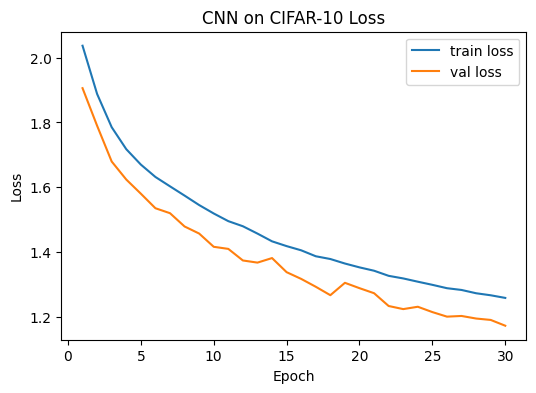

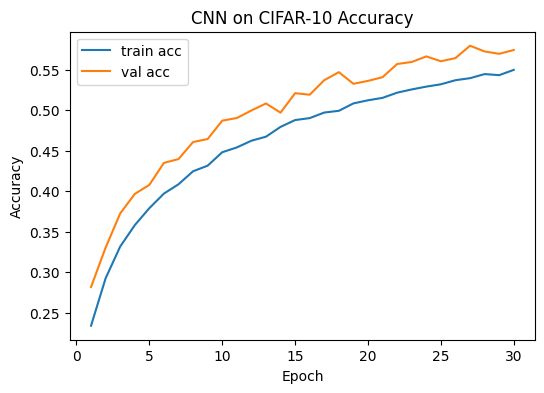

In [28]:
MODEL_NAME = "cnn_v1_cifar_30ep"
if TRAIN_CNN_V1_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN on CIFAR-10")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

Test loss: 1.2056697311873634
Test acc : 0.5793730031948882
Confusion matrix shape: (10, 10)


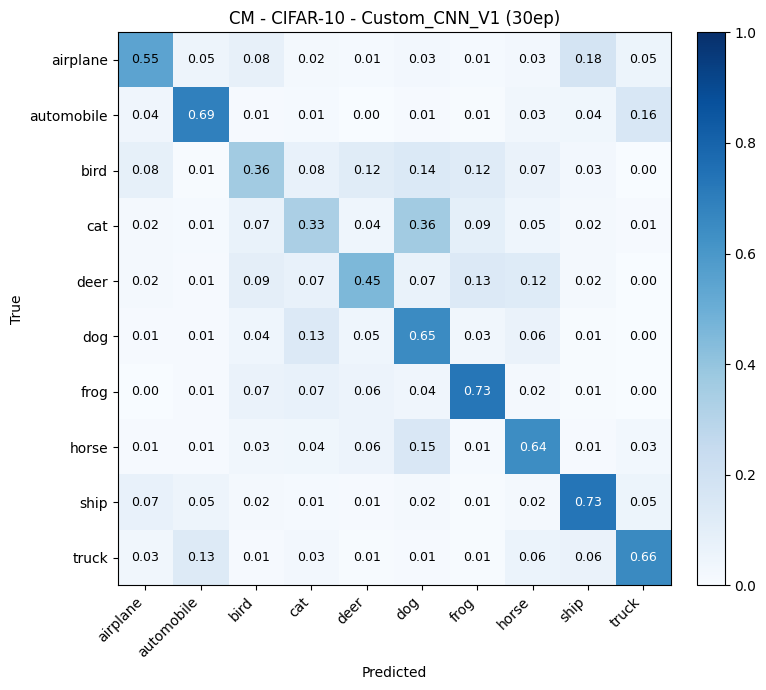

In [29]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_V1 (30ep)")

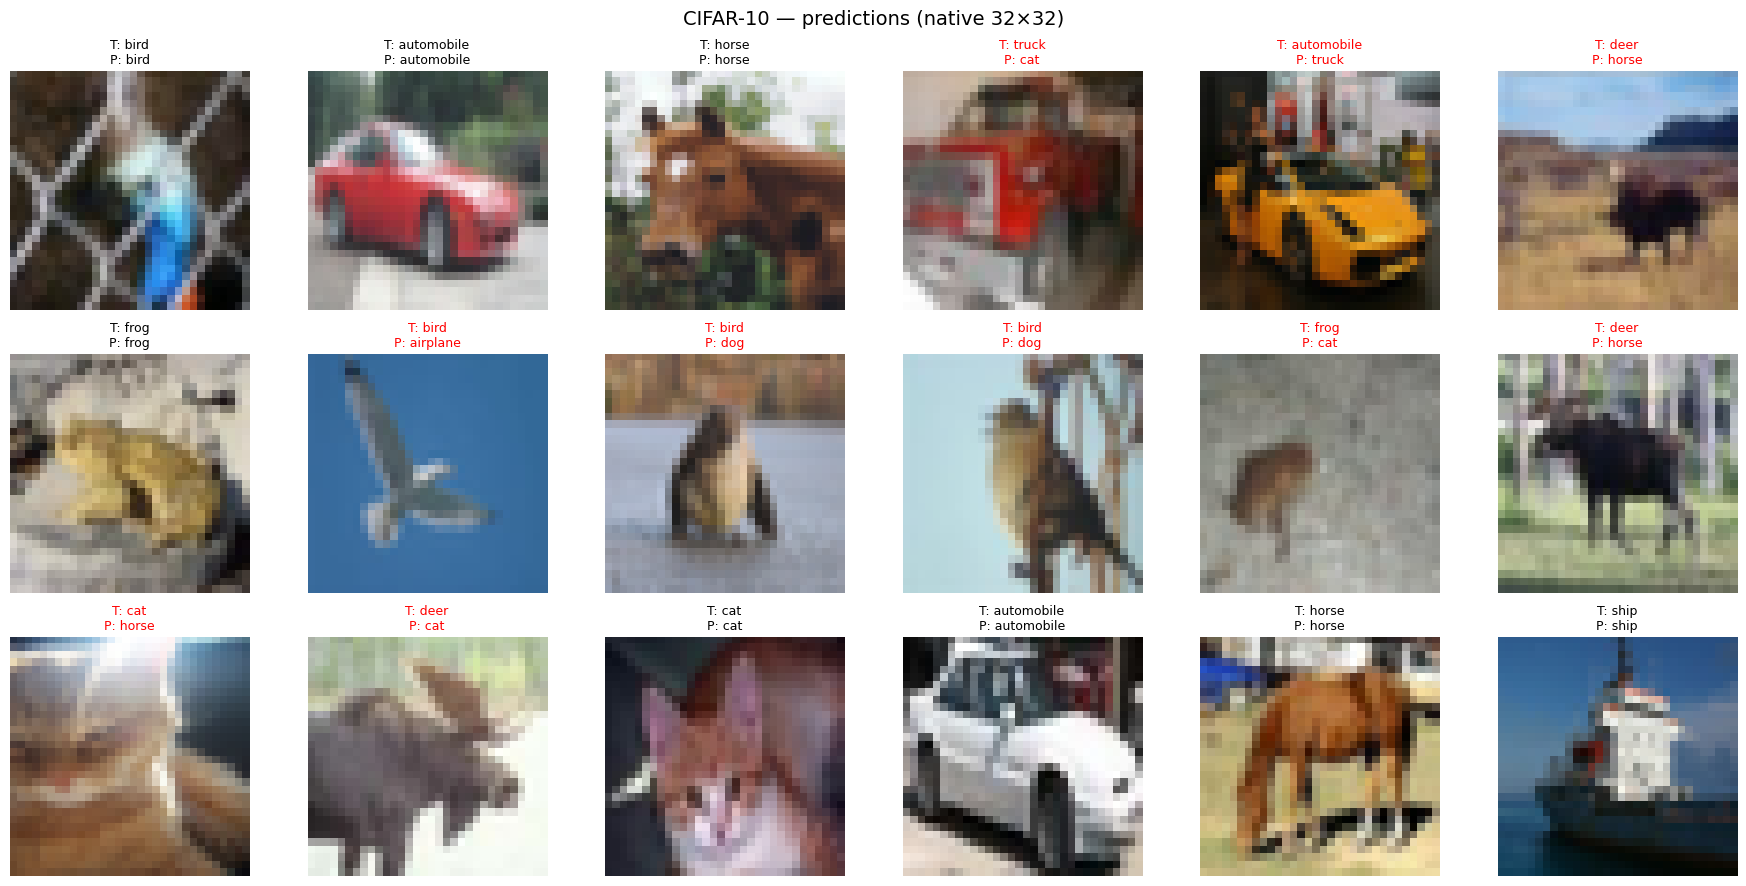

In [30]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")


In [31]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 360
airplane -> ship : 178
automobile -> truck : 156
horse -> dog : 152
bird -> dog : 140
deer -> frog : 134
dog -> cat : 134
truck -> automobile : 130
deer -> horse : 123
bird -> frog : 120


#### 2.1.1bis - CNN - CIFAR-10 (Test CNN "V2")

- CNN_v2 has more conv blocks and uses BatchNorm

epochs:   0%|          | 0/30 [00:00<?, ?it/s]

epochs: 100%|██████████| 30/30 [1:01:13<00:00, 122.46s/it, sec=109, tr_acc=0.675, tr_loss=0.928, va_acc=0.667, va_loss=0.938]



Saved best checkpoint to: weights/project_3/cnn_v2_cifar_30ep_30ep/cnn_v2_cifar_30ep_30ep_model_weights.pth
Metrics: {'best_val_acc': 0.682008785942492, 'best_epoch': 29, 'final_val_acc': 0.682008785942492, 'final_val_macro_f1': 0.6777418450969226, 'final_test_acc': 0.6842052715654952, 'final_test_macro_f1': 0.6814938404617283, 'total_training_time_sec': 3673.760349802, 'train_peak_mem_bytes': 1181895168, 'val_peak_mem_bytes': 455212544, 'test_peak_mem_bytes': 455212544, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}
Saved to: weights/project_3/cnn_v2_cifar_30ep_30ep/cnn_v2_cifar_30ep_30ep_model_weights.pth
Final metrics: {'best_val_acc': 0.682008785942492, 'best_epoch': 29, 'final_val_acc': 0.682008785942492, 'final_val_macro_f1': 0.6777418450969226, 'final_test_acc': 0.6842052715654952, 'final_test_macro_f1': 0.6814938404617283, 'total_training_time_sec': 3673.760349802, 'train_peak_mem_bytes': 1181895168, 'val_peak_mem_bytes': 455212544, 'test_peak_mem_bytes': 455212544, 'device': '

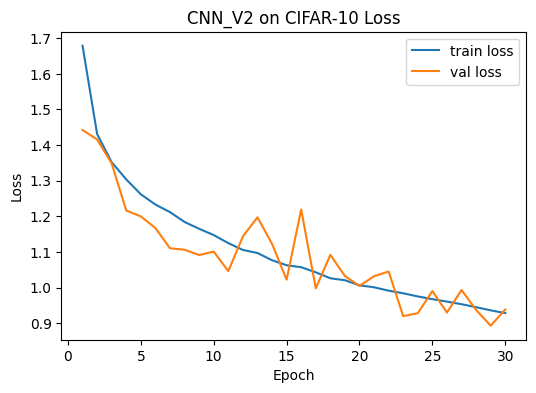

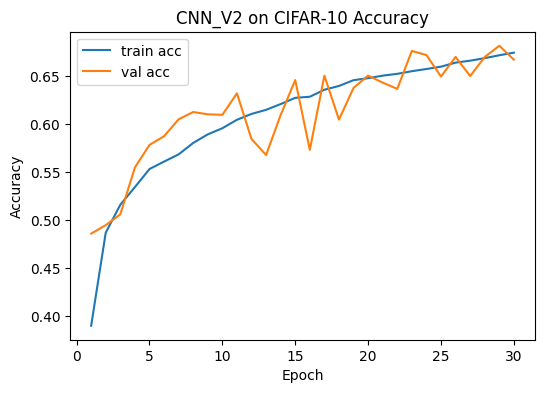

In [22]:
MODEL_NAME = "cnn_v2_cifar_30ep"
if TRAIN_CNN_V2_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)

    model_cnn_cifar, history, metrics, saved_path = train_model(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN_V2 on CIFAR-10")
    
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_cnn_cifar = Custom_CNN_v2(num_classes=cifar_num_classes).to(device)
    model_cnn_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])



Test loss: 0.9039394029032308
Test acc : 0.6842052715654952
Confusion matrix shape: (10, 10)


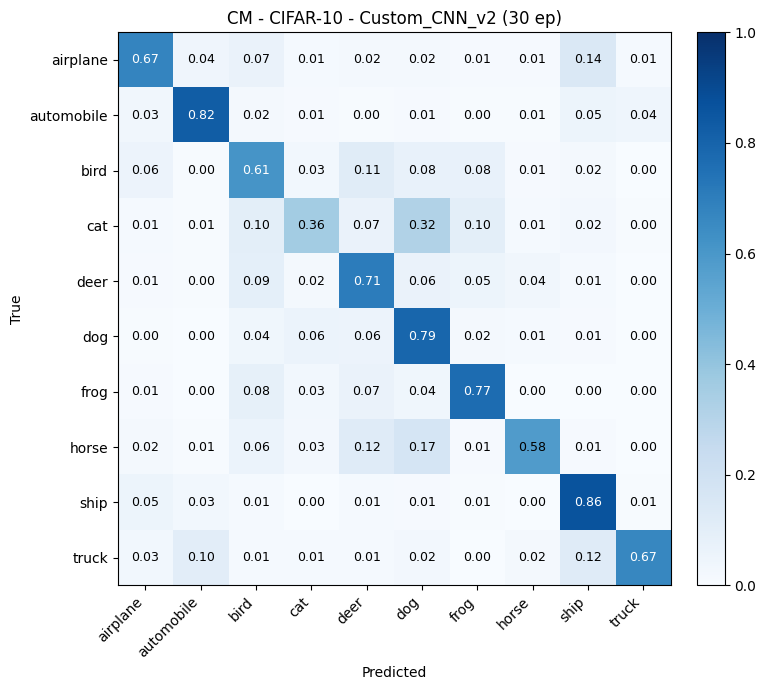

In [26]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - Custom_CNN_v2 (30 ep)")

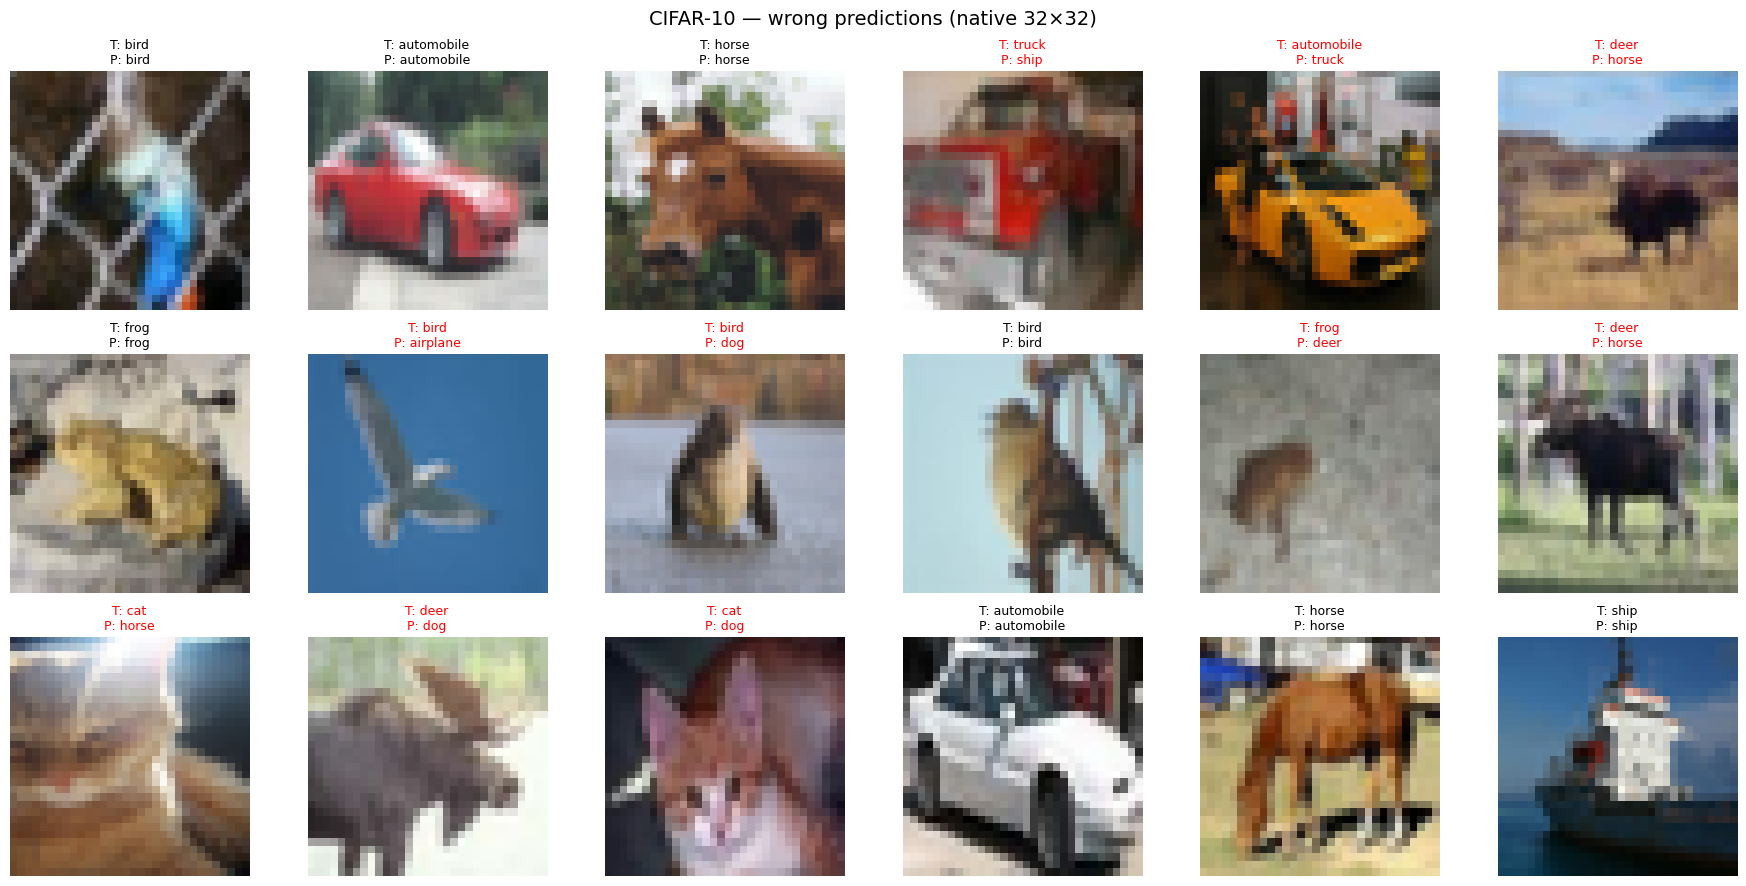

In [ ]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")


In [25]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 316
horse -> dog : 170
airplane -> ship : 142
truck -> ship : 121
horse -> deer : 119
bird -> deer : 114
truck -> automobile : 103
cat -> bird : 101
cat -> frog : 99
deer -> bird : 90


#### 2.1.2 - CNN - FOOD-101

We saw that CNN_v2 gave better results, we will use this model on the food dataset. 

#### 2.1.2 CNN - Food-101 (Test CNN "V2")

In [ ]:
MODEL_NAME = "cnn_v2_food_3ep"
if TRAIN_CNN_V1_FOOD:
    # Training
    food_num_classes = len(food_class_names)
    model_cnn_food = Custom_CNN_v2(num_classes=food_num_classes).to(device)

    model_cnn_food, history, metrics, saved_path = train_model(
        model=model_cnn_food,
        train_loader=food_loaders["train"],
        val_loader=food_loaders["val"],
        test_loader=food_loaders["test"],
        epochs=3,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="CNN on Food-101")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    food_num_classes = len(food_class_names)
    model_cnn_food = Custom_CNN_v2(num_classes=food_num_classes).to(device)
    model_cnn_food.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

epochs:   0%|          | 0/3 [00:00<?, ?it/s]

In [ ]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_cnn_food,
    food_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(food_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (101, 101)
plot_confusion_matrix(cm,food_class_names,title="CM - Food-101 - Custom_CNN_V1 (30ep)")

In [ ]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=True, seed=0)
show_predictions_grid(test_food, idxs, y_true, y_pred, food_class_names,
                          title="Food-101 — wrong predictions")

In [ ]:
top_confusions(y_true, y_pred, food_class_names, top_k=10)

### 2.2 - ResNet-18

Talk about ResNet - comarison with CNN with classification. 

#### 2.2.1 - ResNet-18 - CIFAR-10

epochs: 100%|██████████| 30/30 [47:17<00:00, 94.58s/it, sec=83, tr_acc=0.563, tr_loss=1.219, va_acc=0.592, va_loss=1.136]



Saved best checkpoint to: weights/project_3/cnn_resnet_cifar_30ep_30ep/cnn_resnet_cifar_30ep_30ep_model_weights.pth
Metrics: {'best_val_acc': 0.5947484025559105, 'best_epoch': 25, 'final_val_acc': 0.5947484025559105, 'final_val_macro_f1': 0.5937094216480082, 'final_test_acc': 0.5987420127795527, 'final_test_macro_f1': 0.5975065265306135, 'total_training_time_sec': 2837.5464690610006, 'train_peak_mem_bytes': 821847552, 'val_peak_mem_bytes': 520984576, 'test_peak_mem_bytes': 520984576, 'device': 'cuda', 'lr': 0.0003, 'epochs': 30}
Saved to: weights/project_3/cnn_resnet_cifar_30ep_30ep/cnn_resnet_cifar_30ep_30ep_model_weights.pth
Final metrics: {'best_val_acc': 0.5947484025559105, 'best_epoch': 25, 'final_val_acc': 0.5947484025559105, 'final_val_macro_f1': 0.5937094216480082, 'final_test_acc': 0.5987420127795527, 'final_test_macro_f1': 0.5975065265306135, 'total_training_time_sec': 2837.5464690610006, 'train_peak_mem_bytes': 821847552, 'val_peak_mem_bytes': 520984576, 'test_peak_mem_byte

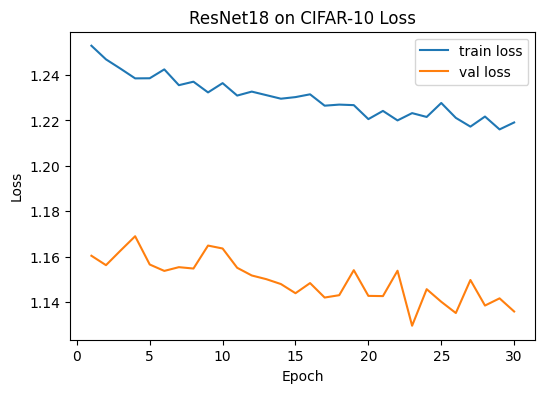

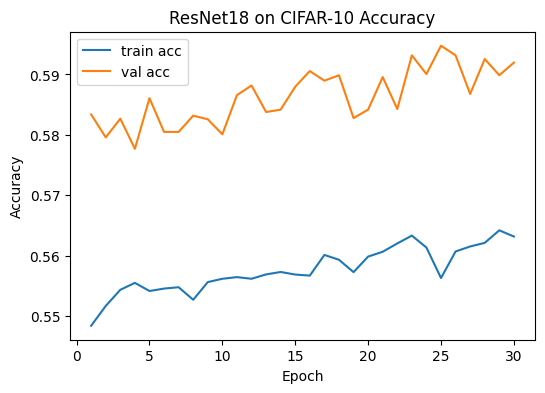

In [73]:
MODEL_NAME = "cnn_resnet_cifar_30ep"
if TRAIN_RESNET_CIFAR:
    # Training
    cifar_num_classes = len(cifar_class_names)
    model_resnet_cifar = ResNet18(num_classes=cifar_num_classes).to(device)

    model_resnet_cifar, history, metrics, saved_path = train_model_resnet(
        model=model_cnn_cifar,
        train_loader=cifar_loaders["train"],
        val_loader=cifar_loaders["val"],
        test_loader=cifar_loaders["test"],
        momentum = 0.9,
        weight_decay = 5e-4,
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="ResNet18 on CIFAR-10")
    
else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    cifar_num_classes = len(cifar_class_names)
    model_resnet_cifar = ResNet18(num_classes=cifar_num_classes).to(device)
    model_resnet_cifar.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

Test loss: 1.147744548016082
Test acc : 0.5987420127795527
Confusion matrix shape: (10, 10)


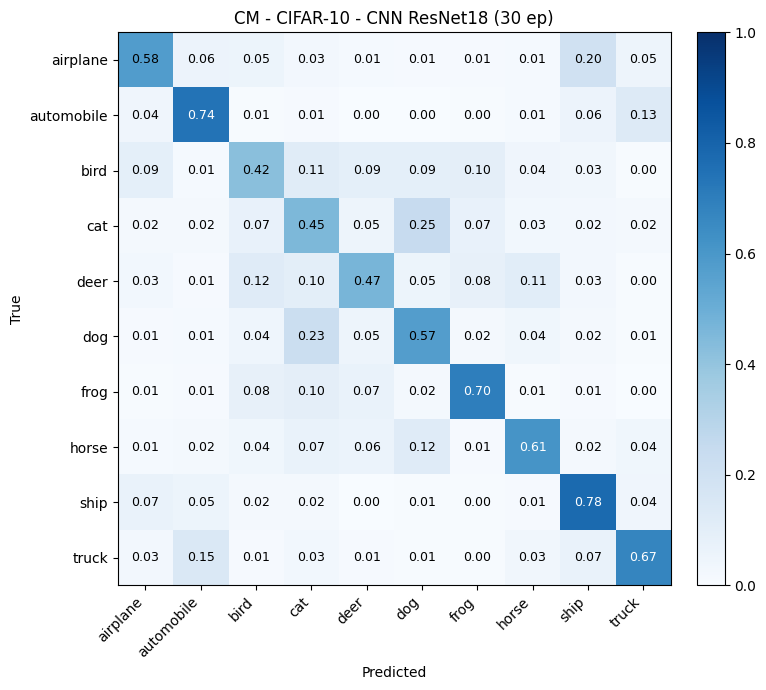

In [74]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_resnet_cifar,
    cifar_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(cifar_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (10, 10)
plot_confusion_matrix(cm,cifar_class_names,title="CM - CIFAR-10 - CNN ResNet18 (30 ep)")

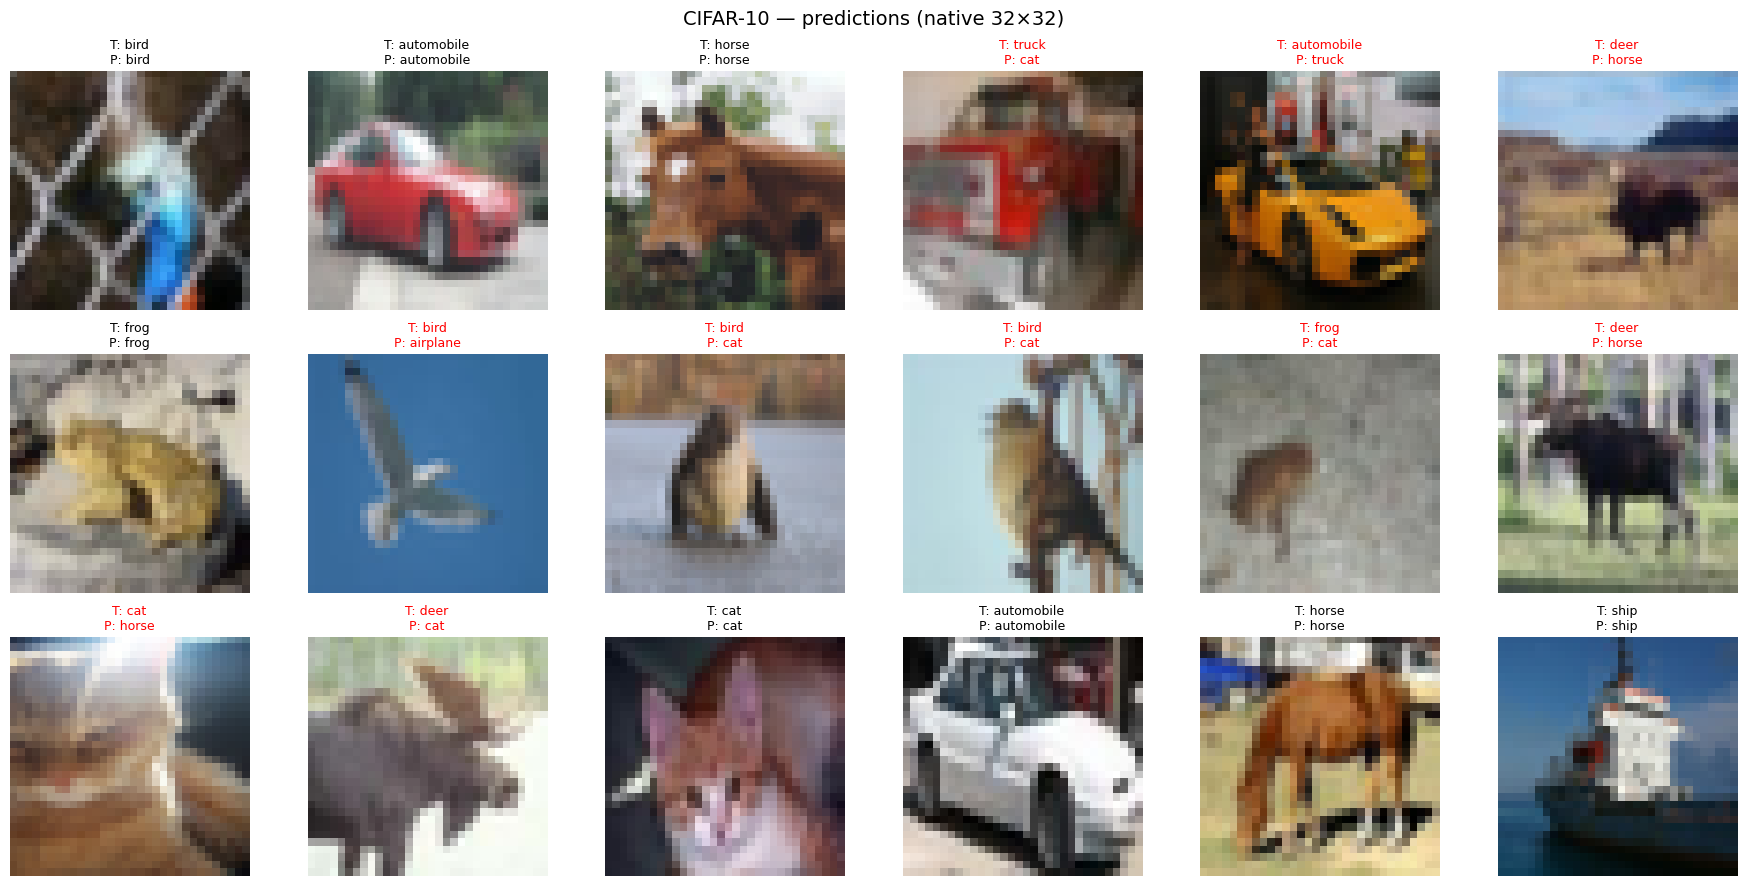

In [75]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid_viz(viz_cifar_test, idxs, y_true, y_pred, cifar_class_names,
                          title="CIFAR-10 — predictions (native 32×32)")


In [76]:
top_confusions(y_true, y_pred, cifar_class_names, top_k=10)

Top 10 confusions (true -> pred : count):
cat -> dog : 246
dog -> cat : 226
airplane -> ship : 197
truck -> automobile : 148
automobile -> truck : 126
deer -> bird : 120
horse -> dog : 118
bird -> cat : 114
deer -> horse : 107
deer -> cat : 100


#### 2.2.2 - ResNet-18 - Food-101

In [ ]:
MODEL_NAME = "cnn_resnet_food_30ep"
if TRAIN_RESNET_FOOD:
    # Training
    food_num_classes = len(food_class_names)
    model_resnet_food = ResNet18(num_classes=food_num_classes).to(device)

    model_resnet_food, history, metrics, saved_path = train_model_resnet(
        model=model_resnet_food,
        train_loader=food_loaders["train"],
        val_loader=food_loaders["val"],
        test_loader=food_loaders["test"],
        momentum = 0.9,
        weight_decay = 5e-4,
        epochs=30,
        lr=3e-4, 
        device=device,
        save_folder_name=f"{MODEL_NAME}",
    )

    print("Saved to:", saved_path)
    print("Final metrics:", metrics)
    plot_history(history, title="ResNet18 on Food-101")

else:
    print(device)
    ckpt_path = f"weights/project_3/{MODEL_NAME}/{MODEL_NAME}_model_weights.pth"
    ckpt = torch.load(ckpt_path, map_location=device)

    food_num_classes = len(food_class_names)
    model_resnet_food = ResNet18(num_classes=food_num_classes).to(device)
    model_resnet_food.load_state_dict(ckpt["model_state_dict"])
    print("Loaded checkpoint keys:", ckpt.keys())
    if "metrics" in ckpt:
        print("Saved metrics:", ckpt["metrics"])

In [ ]:
# Evaluate
criterion = nn.CrossEntropyLoss()

test_loss, test_acc, _, y_true, y_pred = evaluate(
    model_resnet_food,
    food_loaders["test"],
    criterion,
    device,
    return_preds=True
)

cm = confusion_matrix(
    y_true, y_pred,
    labels=list(range(food_num_classes))
)

print("Test loss:", test_loss)
print("Test acc :", test_acc)

print("Confusion matrix shape:", cm.shape)  # should be (101, 101)
plot_confusion_matrix(cm,food_class_names,title="CM - Food-101 - CNN ResNet18 (30 ep)")

In [ ]:
idxs = pick_indices(y_true, y_pred, n=18, only_errors=False, seed=0)
show_predictions_grid(test_food, idxs, y_true, y_pred, food_class_names,
                          title="Food-101 — predictions")

In [ ]:
top_confusions(y_true, y_pred, food_class_names, top_k=10)

## 3 - Vision Transformers

### 3.1 - VisionTransformer-Tiny (ViT-Tiny)

### 3.2 - Swin Transformer-Tiny (Swin-Tiny)

## 4 - Comparison

Comparison with literature

## 5 - Conclusion